# Car Parts Preprocessing

## 1. Objective

This notebook inspects and validates the Carparts-Seg dataset before model training. It examines the dataset structure, class definitions, split sizes, image-label consistency, annotation validity, class distribution, and segmentation-mask quality.

## 2. Imports and Configuration

In [58]:
from pathlib import Path
from collections import Counter
import random

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from matplotlib.patches import Polygon
import hashlib

In [3]:
DATASET_ROOT = Path("../data/carparts-seg").resolve()

In [4]:
print("Dataset root:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())

Dataset root: C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg
Dataset exists: True


## 3. Dataset Configuration

In [6]:
YAML_PATH = DATASET_ROOT / "carparts-seg.yaml"

print("Configuration file:", YAML_PATH)
print("Configuration file exists:", YAML_PATH.exists())

Configuration file: C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\carparts-seg.yaml
Configuration file exists: True


In [7]:
with open(YAML_PATH, "r", encoding="utf-8") as file:
    dataset_config = yaml.safe_load(file)

dataset_config

{'path': 'carparts-seg',
 'train': 'images/train',
 'val': 'images/val',
 'test': 'images/test',
 'names': {0: 'back_bumper',
  1: 'back_door',
  2: 'back_glass',
  3: 'back_left_door',
  4: 'back_left_light',
  5: 'back_light',
  6: 'back_right_door',
  7: 'back_right_light',
  8: 'front_bumper',
  9: 'front_door',
  10: 'front_glass',
  11: 'front_left_door',
  12: 'front_left_light',
  13: 'front_light',
  14: 'front_right_door',
  15: 'front_right_light',
  16: 'hood',
  17: 'left_mirror',
  18: 'object',
  19: 'right_mirror',
  20: 'tailgate',
  21: 'trunk',
  22: 'wheel'},
 'download': 'https://github.com/ultralytics/assets/releases/download/v0.0.0/carparts-seg.zip'}

## 4. Class Definitions


In [8]:
class_names = dataset_config["names"]
number_of_classes = len(class_names)

print("Number of classes:", number_of_classes)

Number of classes: 23


In [9]:
classes_df = pd.DataFrame(
    class_names.items(),
    columns=["Class ID", "Class Name"]
)

classes_df

,Class ID,Class Name
0,0,back_bumper
1,1,back_door
2,2,back_glass
3,3,back_left_door
4,4,back_left_light
5,5,back_light
6,6,back_right_door
7,7,back_right_light
8,8,front_bumper
9,9,front_door


In [10]:
expected_class_ids = list(range(number_of_classes))
actual_class_ids = sorted(class_names.keys())

class_ids_are_contiguous = actual_class_ids == expected_class_ids

class_ids_are_contiguous

True

## 5. Dataset Split Validation


In [11]:
splits = ["train", "val", "test"]

for split in splits:
    image_dir = DATASET_ROOT / dataset_config[split]
    label_dir = DATASET_ROOT / "labels" / split

    print(f"{split.upper()}")
    print(f"  Images: {image_dir.exists()} - {image_dir}")
    print(f"  Labels: {label_dir.exists()} - {label_dir}")

TRAIN
  Images: True - C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\images\train
  Labels: True - C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\labels\train
VAL
  Images: True - C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\images\val
  Labels: True - C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\labels\val
TEST
  Images: True - C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\images\test
  Labels: True - C:\Users\Hai-1\Desktop\qaddir-vehicle-damage-assessment\data\carparts-seg\labels\test


### 5.1 Split Size Summary

In [15]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

split_summary = []

for split in splits:
    image_dir = DATASET_ROOT / dataset_config[split]
    label_dir = DATASET_ROOT / "labels" / split

    image_files = [
        path for path in image_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    label_files = list(label_dir.glob("*.txt"))

    split_summary.append({
        "Split": split,
        "Images": len(image_files),
        "Label Files": len(label_files),
        "Difference": len(image_files) - len(label_files)
    })

split_summary_df = pd.DataFrame(split_summary)
split_summary_df

,Split,Images,Label Files,Difference
0,train,3156,3156,0
1,val,401,401,0
2,test,276,276,0


### 5.2 Image–Label Pairing


In [16]:
pairing_results = []

for split in splits:
    image_dir = DATASET_ROOT / dataset_config[split]
    label_dir = DATASET_ROOT / "labels" / split

    image_stems = {
        path.stem
        for path in image_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    }

    label_stems = {
        path.stem
        for path in label_dir.glob("*.txt")
    }

    images_without_labels = image_stems - label_stems
    labels_without_images = label_stems - image_stems

    pairing_results.append({
        "Split": split,
        "Images Without Labels": len(images_without_labels),
        "Labels Without Images": len(labels_without_images)
    })

pairing_results_df = pd.DataFrame(pairing_results)
pairing_results_df

,Split,Images Without Labels,Labels Without Images
0,train,0,0
1,val,0,0
2,test,0,0


## 6. Annotation Format Inspection


In [17]:
train_label_dir = DATASET_ROOT / "labels" / "train"
sample_label_path = sorted(train_label_dir.glob("*.txt"))[0]

with open(sample_label_path, "r", encoding="utf-8") as file:
    sample_lines = file.readlines()

print("Sample label:", sample_label_path.name)
print("Number of annotated instances:", len(sample_lines))
print("First annotation line:")
print(sample_lines[0])

Sample label: car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt
Number of annotated instances: 10
First annotation line:
2 0.46689453125 0.5880371656250001 0.5666015625 0.5780487812499999 0.63115234375 0.5738675953125 0.67255859375 0.5731707312500001 0.620703125 0.533565621875 0.5791015625 0.5063879203125 0.55830078125 0.503948896875 0.45654296875 0.503948896875 0.4076171875 0.5101045296875 0.43779296875 0.5558652734375 0.46689453125 0.5880371656250001



In [18]:
values = sample_lines[0].strip().split()

class_id = int(values[0])
coordinates = np.array(values[1:], dtype=float).reshape(-1, 2)

print("Class ID:", class_id)
print("Class name:", class_names[class_id])
print("Number of polygon points:", len(coordinates))
print("First five points:")
print(coordinates[:5])

Class ID: 2
Class name: back_glass
Number of polygon points: 11
First five points:
[[0.46689453 0.58803717]
 [0.56660156 0.57804878]
 [0.63115234 0.5738676 ]
 [0.67255859 0.57317073]
 [0.62070313 0.53356562]]


## 7. Annotation Validation


In [20]:
all_label_paths = []

for split in splits:
    label_dir = DATASET_ROOT / "labels" / split
    all_label_paths.extend(label_dir.glob("*.txt"))

print("Total label files:", len(all_label_paths))

Total label files: 3833


### 7.1 Empty Label Files


In [21]:
empty_label_files = []

for label_path in all_label_paths:
    content = label_path.read_text(encoding="utf-8").strip()

    if not content:
        empty_label_files.append(label_path)

print("Empty label files:", len(empty_label_files))

Empty label files: 135


In [23]:
empty_labels_df["Total Images"] = empty_labels_df["Split"].map(
    dict(zip(split_summary_df["Split"], split_summary_df["Images"]))
)

empty_labels_df["Empty Label Percentage"] = (
    empty_labels_df["Empty Label Files"]
    / empty_labels_df["Total Images"]
    * 100
).round(2)

empty_labels_df

,Split,Empty Label Files,Total Images,Empty Label Percentage
0,train,116,3156,3.68
1,val,12,401,2.99
2,test,7,276,2.54


In [24]:
rng = random.Random(42)
empty_label_samples = []

for split in splits:
    split_empty_labels = [
        path for path in empty_label_files
        if path.parent.name == split
    ]

    selected_labels = rng.sample(
        split_empty_labels,
        k=min(2, len(split_empty_labels))
    )

    empty_label_samples.extend(selected_labels)

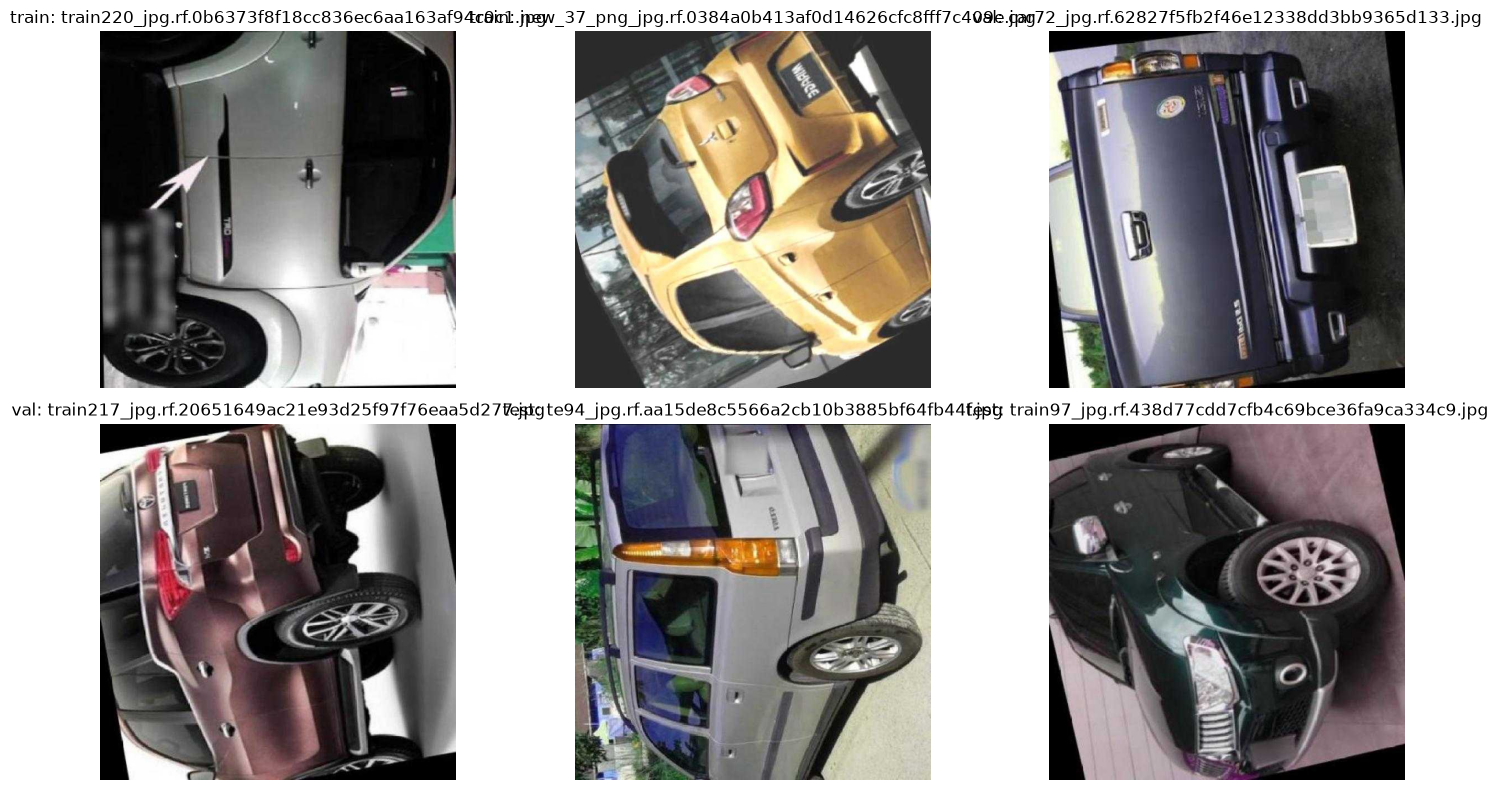

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for axis, label_path in zip(axes, empty_label_samples):
    split = label_path.parent.name
    image_path = (
        DATASET_ROOT
        / "images"
        / split
        / f"{label_path.stem}.jpg"
    )

    image = Image.open(image_path).convert("RGB")

    axis.imshow(image)
    axis.set_title(f"{split}: {image_path.name}")
    axis.axis("off")

plt.tight_layout()
plt.show()

**Finding:** The inspected sample of images with empty label files contained clearly visible vehicle parts. This suggests potential missing annotations rather than valid negative samples. The 135 empty-label images should be flagged for further review before model training or evaluation.

### 7.2 Class ID Validation


In [26]:
invalid_class_ids = []

for label_path in all_label_paths:
    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line_number, line in enumerate(lines, start=1):
        if not line.strip():
            continue

        first_value = line.split()[0]

        try:
            class_id = int(first_value)

            if class_id not in class_names:
                invalid_class_ids.append(
                    (label_path, line_number, first_value)
                )

        except ValueError:
            invalid_class_ids.append(
                (label_path, line_number, first_value)
            )

print("Invalid class IDs:", len(invalid_class_ids))

Invalid class IDs: 0


**Finding:** All non-empty annotation files contain valid class identifiers within the configured range of 0 to 22.

### 7.3 Coordinate Count Validation


In [28]:
odd_coordinate_lines = []

for label_path in all_label_paths:
    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line_number, line in enumerate(lines, start=1):
        if not line.strip():
            continue

        values = line.split()
        coordinate_count = len(values) - 1

        if coordinate_count % 2 != 0:
            odd_coordinate_lines.append(
                (label_path, line_number, coordinate_count)
            )

print("Lines with an odd number of coordinates:", len(odd_coordinate_lines))

Lines with an odd number of coordinates: 0


**Finding:** All non-empty annotation lines contain an even number of coordinate values.

### 7.4 Minimum Polygon Points


In [ ]:
insufficient_polygon_points = []

for label_path in all_label_paths:
    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line_number, line in enumerate(lines, start=1):
        if not line.strip():
            continue

        coordinate_count = len(line.split()) - 1
        point_count = coordinate_count // 2

        if point_count < 3:
            insufficient_polygon_points.append(
                (label_path, line_number, point_count)
            )

print("Polygons with fewer than three points:", len(insufficient_polygon_points))

Polygons with fewer than three points: 0


**Finding:** All segmentation polygons contain at least three coordinate points.

### 7.5 Numeric Coordinate Validation


In [30]:
non_numeric_coordinates = []

for label_path in all_label_paths:
    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line_number, line in enumerate(lines, start=1):
        if not line.strip():
            continue

        coordinate_values = line.split()[1:]

        try:
            np.array(coordinate_values, dtype=float)

        except ValueError:
            non_numeric_coordinates.append(
                (label_path, line_number)
            )

print("Lines with non-numeric coordinates:", len(non_numeric_coordinates))

Lines with non-numeric coordinates: 0


**Finding:** All polygon coordinate values are numeric.

### 7.6 Coordinate Range Validation


In [31]:
out_of_range_coordinates = []

for label_path in all_label_paths:
    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line_number, line in enumerate(lines, start=1):
        if not line.strip():
            continue

        coordinates = np.array(
            line.split()[1:],
            dtype=float
        )

        coordinates_are_valid = (
            (coordinates >= 0) & (coordinates <= 1)
        ).all()

        if not coordinates_are_valid:
            out_of_range_coordinates.append(
                (label_path, line_number)
            )

print("Lines with coordinates outside 0–1:", len(out_of_range_coordinates))

Lines with coordinates outside 0–1: 0


### Annotation Validation Summary

All non-empty annotation files passed the structural validation checks. Class identifiers, coordinate counts, polygon-point counts, numeric values, and normalized coordinate ranges were valid. However, 135 empty annotation files were identified and flagged for further review.

## 8. Class Distribution


In [33]:
class_instance_counts = Counter()

for label_path in all_label_paths:
    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line in lines:
        if not line.strip():
            continue

        class_id = int(line.split()[0])
        class_instance_counts[class_id] += 1

In [34]:
class_distribution_rows = []

for class_id, class_name in class_names.items():
    class_distribution_rows.append({
        "Class ID": class_id,
        "Class Name": class_name,
        "Instances": class_instance_counts[class_id]
    })

class_distribution_df = pd.DataFrame(class_distribution_rows)
class_distribution_df

,Class ID,Class Name,Instances
0,0,back_bumper,870
1,1,back_door,1252
2,2,back_glass,1058
3,3,back_left_door,255
4,4,back_left_light,291
5,5,back_light,1902
6,6,back_right_door,224
7,7,back_right_light,241
8,8,front_bumper,1978
9,9,front_door,1409


In [35]:
print("Total annotated instances:", class_distribution_df["Instances"].sum())

Total annotated instances: 20374


### 8.1 Class Frequency Visualization


In [36]:
total_instances = class_distribution_df["Instances"].sum()

class_distribution_df["Percentage"] = (
    class_distribution_df["Instances"]
    / total_instances
    * 100
).round(2)

In [37]:
class_distribution_sorted = class_distribution_df.sort_values(
    by="Instances",
    ascending=True
)

class_distribution_sorted

,Class ID,Class Name,Instances,Percentage
18,18,object,12,0.06
20,20,tailgate,101,0.50
21,21,trunk,173,0.85
6,6,back_right_door,224,1.10
7,7,back_right_light,241,1.18
14,14,front_right_door,248,1.22
3,3,back_left_door,255,1.25
11,11,front_left_door,279,1.37
4,4,back_left_light,291,1.43
15,15,front_right_light,474,2.33


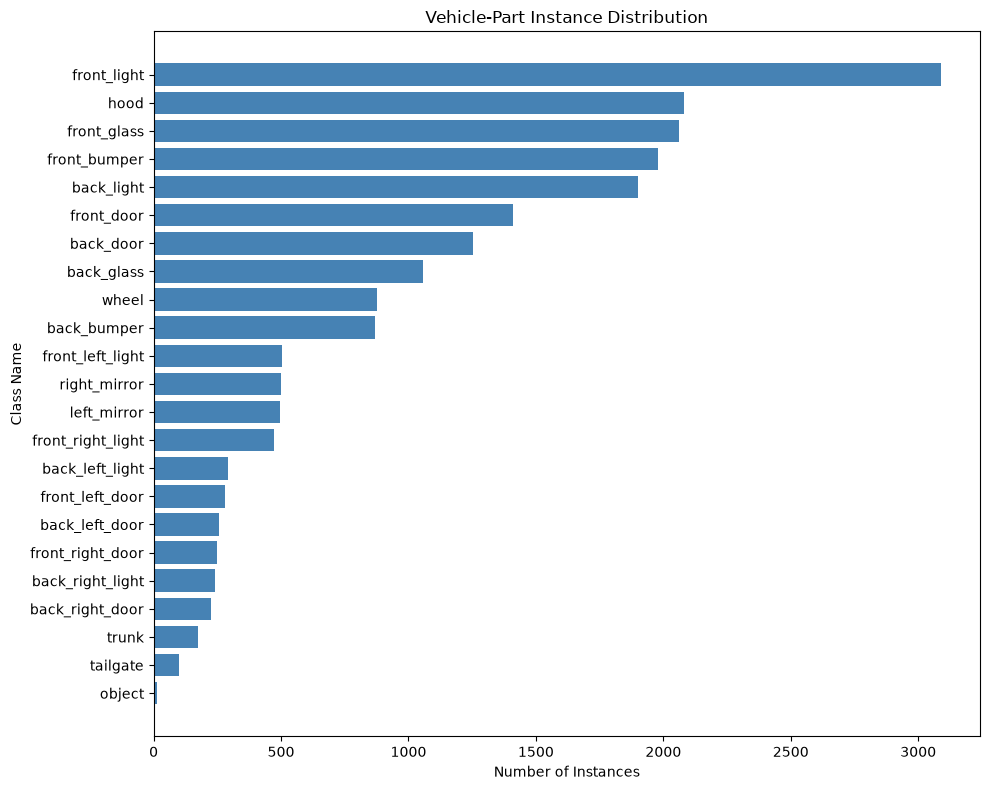

In [38]:
plt.figure(figsize=(10, 8))

plt.barh(
    class_distribution_sorted["Class Name"],
    class_distribution_sorted["Instances"],
    color="steelblue"
)

plt.title("Vehicle-Part Instance Distribution")
plt.xlabel("Number of Instances")
plt.ylabel("Class Name")

plt.tight_layout()
plt.show()

**Finding:** The class distribution shows noticeable imbalance across the 23 vehicle-part categories. Some classes contain substantially more annotated instances than others, which may influence model performance and should be considered during training and class-level evaluation.

## 9. Segmentation Mask Visualization


In [47]:
def plot_segmentation_sample(
    axis,
    label_path,
    target_class_id=None
):
    split = label_path.parent.name
    image_path = (
        DATASET_ROOT
        / "images"
        / split
        / f"{label_path.stem}.jpg"
    )

    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    axis.imshow(image)

    annotation_lines = label_path.read_text(
        encoding="utf-8"
    ).splitlines()

    for line in annotation_lines:
        if not line.strip():
            continue

        values = line.split()
        class_id = int(values[0])

        # Display all classes unless a target class is specified
        if (
            target_class_id is not None
            and class_id != target_class_id
        ):
            continue

        normalized_points = np.array(
            values[1:],
            dtype=float
        ).reshape(-1, 2)

        pixel_points = normalized_points * [width, height]
        color = plt.cm.tab20(class_id % 20)

        axis.add_patch(
            Polygon(
                pixel_points,
                closed=True,
                facecolor=color,
                edgecolor=color,
                alpha=0.4,
                linewidth=2
            )
        )

        label_x, label_y = pixel_points[0]

        axis.text(
            label_x,
            label_y,
            class_names[class_id],
            fontsize=8,
            color="white",
            bbox={
                "facecolor": color,
                "alpha": 0.8,
                "edgecolor": "none"
            }
        )

    axis.set_title(f"{split} | {image_path.stem[:18]}")
    axis.axis("off")

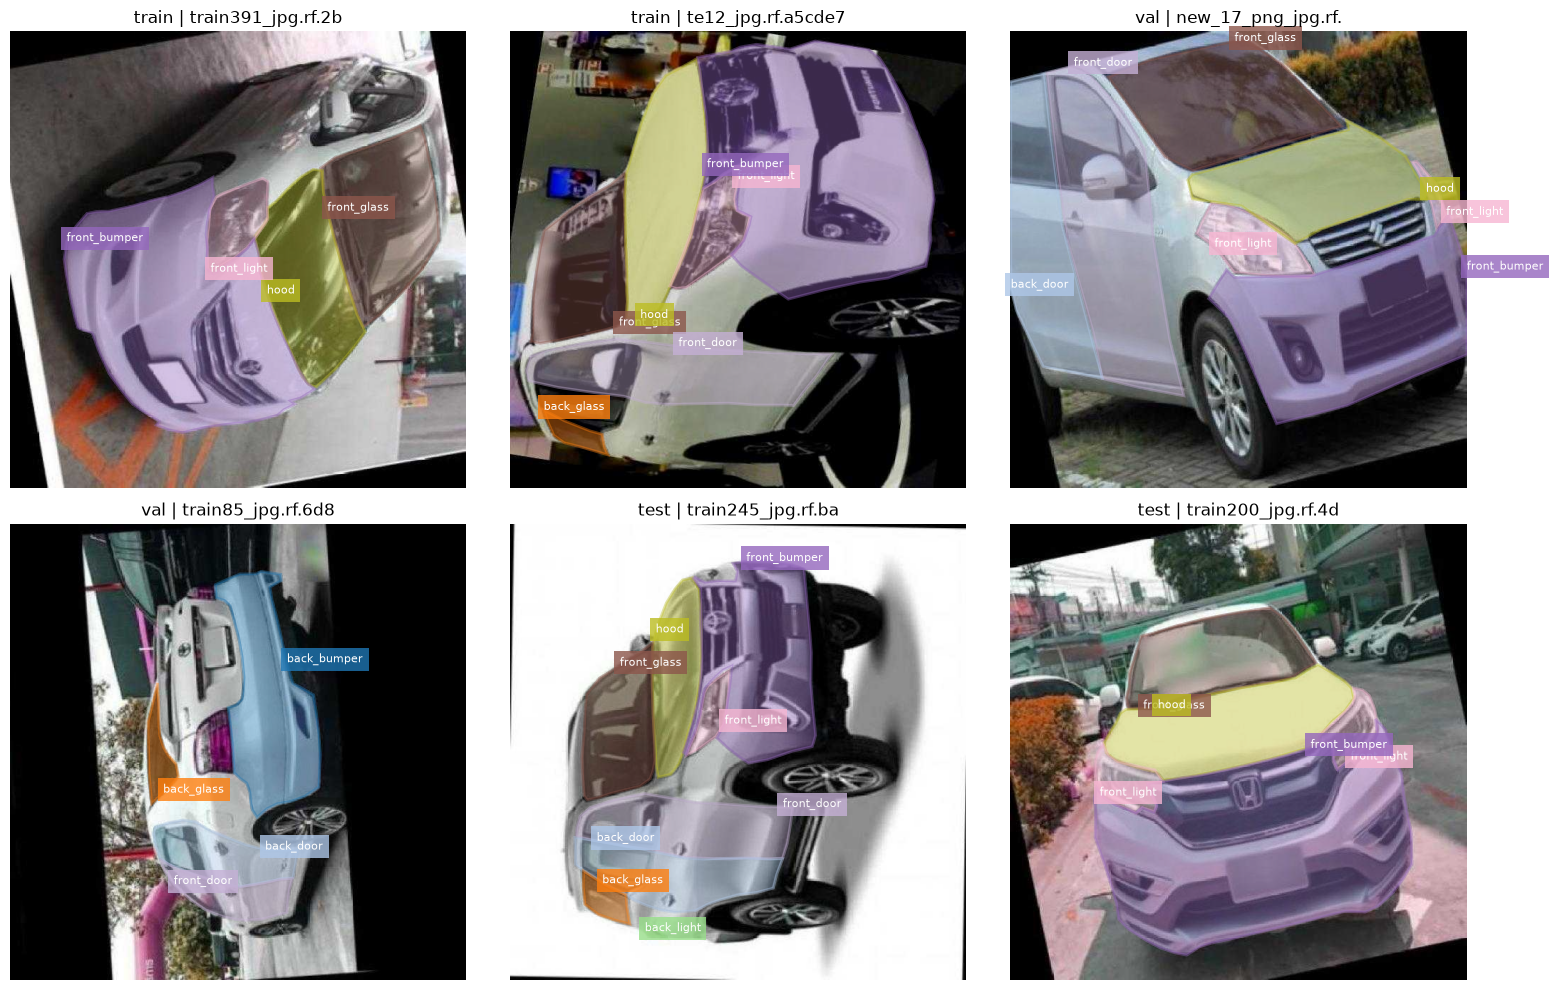

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for axis, label_path in zip(
    axes.flatten(),
    visualization_samples
):
    plot_segmentation_sample(axis, label_path)

plt.tight_layout()
plt.show()

**Finding:** The sampled segmentation masks generally align with the corresponding vehicle parts, confirming that the normalized polygon coordinates are interpreted correctly. However, some visible vehicle parts appear to be unannotated, and several masks have approximate or overlapping boundaries. Rotated images are also present, although their annotations remain spatially aligned.

## 10. Object Class Review


In [45]:
object_class_id = next(
    class_id
    for class_id, class_name in class_names.items()
    if class_name == "object"
)

print("Object class ID:", object_class_id)

Object class ID: 18


In [46]:
object_label_paths = []

for label_path in all_label_paths:
    lines = label_path.read_text(
        encoding="utf-8"
    ).splitlines()

    for line in lines:
        if not line.strip():
            continue

        class_id = int(line.split()[0])

        if class_id == object_class_id:
            object_label_paths.append(label_path)
            break

print("Images containing the object class:", len(object_label_paths))

Images containing the object class: 12


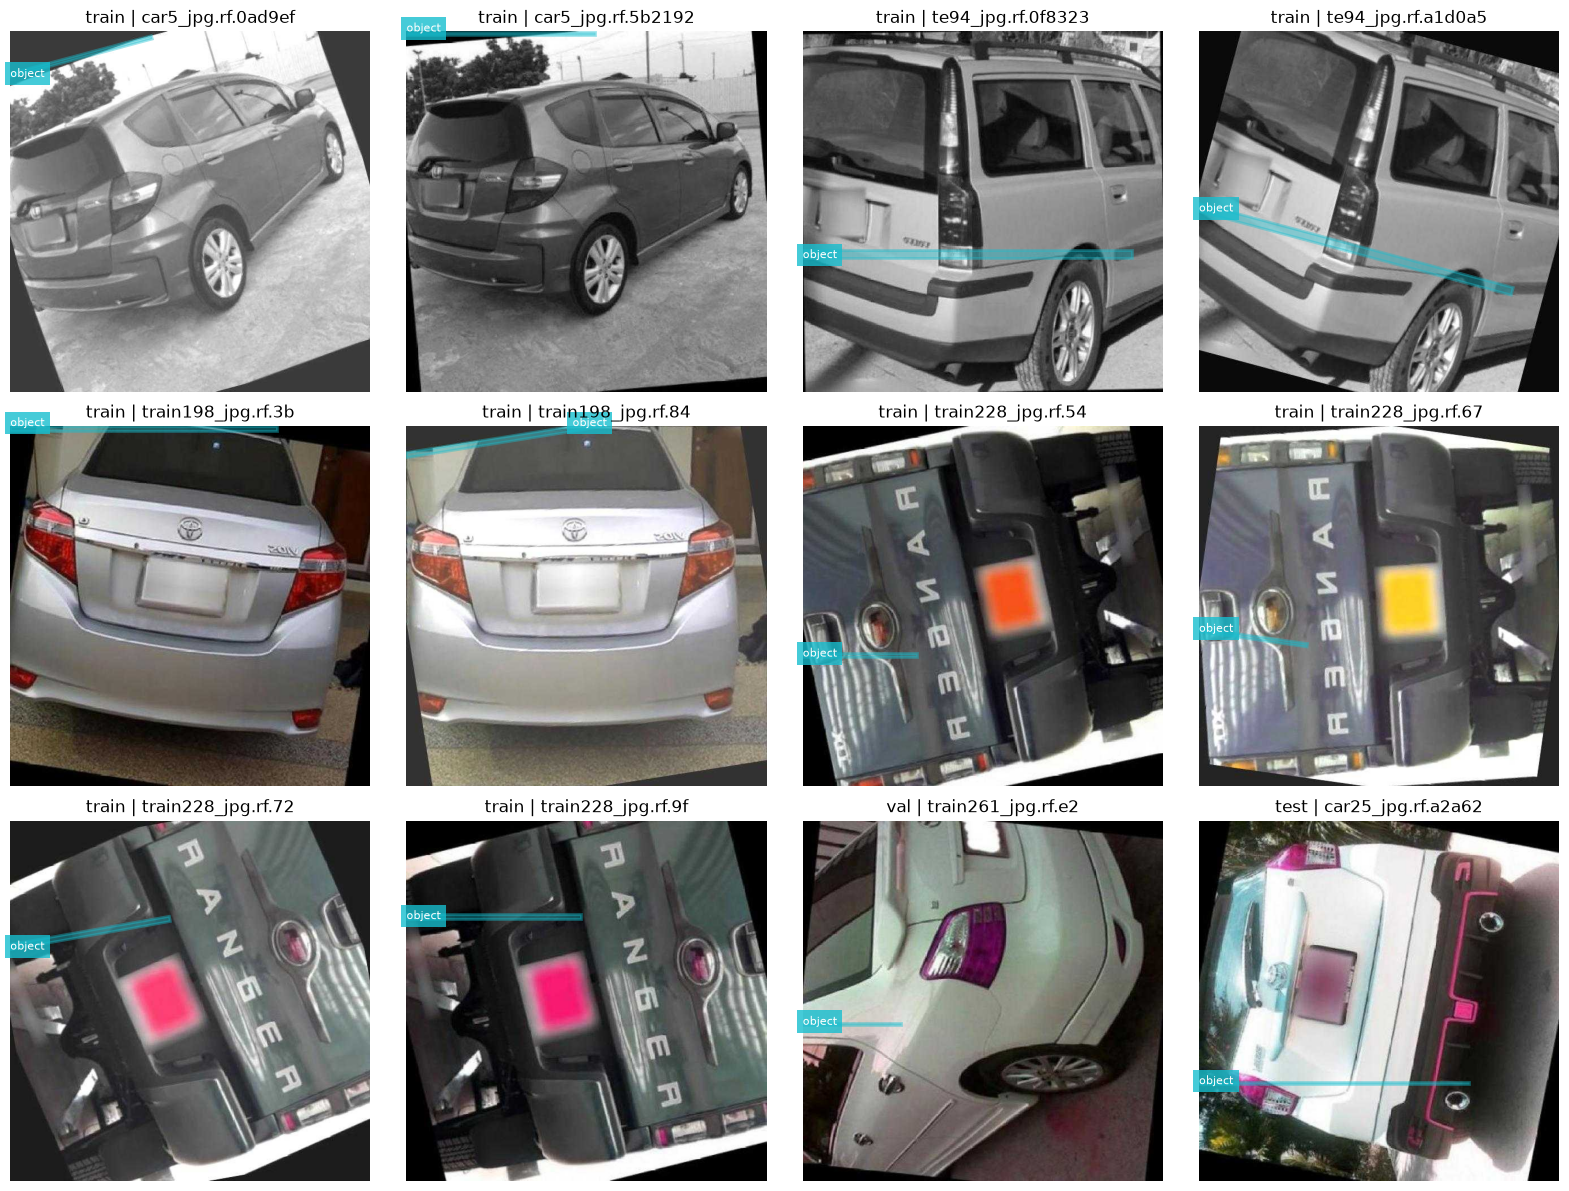

In [48]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for axis, label_path in zip(
    axes.flatten(),
    object_label_paths
):
    plot_segmentation_sample(
        axis,
        label_path,
        target_class_id=object_class_id
    )

plt.tight_layout()
plt.show()

**Finding:** The `object` class appears in only 12 images. Visual inspection shows thin, near-linear annotations that do not consistently delineate a recognizable vehicle part. This class should be excluded or re-annotated before model training, pending confirmation from the dataset source.

### 7.7 Polygon Area Validation


In [49]:
def calculate_polygon_area(points):
    x = points[:, 0]
    y = points[:, 1]

    return 0.5 * abs(
        np.dot(x, np.roll(y, -1))
        - np.dot(y, np.roll(x, -1))
    )

In [50]:
polygon_area_records = []

for label_path in all_label_paths:
    lines = label_path.read_text(
        encoding="utf-8"
    ).splitlines()

    for line_number, line in enumerate(lines, start=1):
        if not line.strip():
            continue

        values = line.split()
        class_id = int(values[0])

        points = np.array(
            values[1:],
            dtype=float
        ).reshape(-1, 2)

        normalized_area = calculate_polygon_area(points)

        polygon_area_records.append({
            "Split": label_path.parent.name,
            "File": label_path.name,
            "Line": line_number,
            "Class ID": class_id,
            "Class Name": class_names[class_id],
            "Normalized Area": normalized_area,
            "Area Percentage": normalized_area * 100
        })

polygon_areas_df = pd.DataFrame(polygon_area_records)

polygon_areas_df.head()

,Split,File,Line,Class ID,Class Name,Normalized Area,Area Percentage
0,train,car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt,1,2,back_glass,0.014865,1.486490
1,train,car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt,2,20,tailgate,0.032861,3.286144
2,train,car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt,3,4,back_left_light,0.008323,0.832332
3,train,car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt,4,7,back_right_light,0.002134,0.213385
4,train,car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt,5,0,back_bumper,0.043489,4.348909


In [51]:
zero_area_polygons = polygon_areas_df[
    np.isclose(
        polygon_areas_df["Normalized Area"],
        0,
        atol=1e-10
    )
]

print("Zero-area polygons:", len(zero_area_polygons))

Zero-area polygons: 0


In [52]:
polygon_areas_df[
    ["Normalized Area", "Area Percentage"]
].describe()

,Normalized Area,Area Percentage
count,20374.000000,20374.000000
mean,0.055976,5.597630
std,0.066182,6.618169
min,0.000165,0.016461
25%,0.010251,1.025050
50%,0.037080,3.708025
75%,0.075362,7.536171
max,0.529099,52.909921


**Finding:** No zero-area polygons were detected. However, visual inspection showed that the `object` class remains semantically unclear and contains thin, inconsistent masks. It should be reviewed or excluded before training.

## 11. Image Integrity and Dimensions


In [53]:
all_image_paths = []

for split in splits:
    image_dir = DATASET_ROOT / dataset_config[split]

    split_image_paths = [
        path
        for path in image_dir.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    all_image_paths.extend(split_image_paths)

print("Total image files:", len(all_image_paths))

Total image files: 3833


In [54]:
image_records = []
corrupted_images = []

for image_path in all_image_paths:
    try:
        with Image.open(image_path) as image:
            image.load()
            width, height = image.size

        if width > height:
            orientation = "Landscape"
        elif height > width:
            orientation = "Portrait"
        else:
            orientation = "Square"

        image_records.append({
            "Split": image_path.parent.name,
            "File": image_path.name,
            "Width": width,
            "Height": height,
            "Orientation": orientation
        })

    except Exception as error:
        corrupted_images.append({
            "Split": image_path.parent.name,
            "File": image_path.name,
            "Error": str(error)
        })

In [55]:
images_df = pd.DataFrame(image_records)

print("Valid images:", len(images_df))
print("Corrupted images:", len(corrupted_images))

Valid images: 3833
Corrupted images: 0


In [56]:
images_df[["Width", "Height"]].describe()

,Width,Height
count,3833.0,3833.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


In [57]:
orientation_summary = (
    images_df["Orientation"]
    .value_counts()
    .rename_axis("Orientation")
    .reset_index(name="Images")
)

orientation_summary

,Orientation,Images
0,Square,3833


**Finding:** All 3,833 images were successfully decoded, and no corrupted files were detected. Every image has a consistent resolution of 640 × 640 pixels, indicating that resizing was already applied before this analysis.

## 12. Exact Duplicate Check


In [59]:
image_hash_records = []

for image_path in all_image_paths:
    image_hash = hashlib.sha256(
        image_path.read_bytes()
    ).hexdigest()

    image_hash_records.append({
        "Split": image_path.parent.name,
        "File": image_path.name,
        "Hash": image_hash
    })

image_hashes_df = pd.DataFrame(image_hash_records)
image_hashes_df.head()

,Split,File,Hash
0,train,car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.jpg,39425e9afb2d62203bfe5ac3f8b7223c552e034436a779...
1,train,car10_jpg.rf.291cfe46c25830e83dd4283cb304d159.jpg,e843e83707ddecb8cbeab3a9a9d76947fa1eb5f8c2f877...
2,train,car10_jpg.rf.2f776f55ff2ce1799469b62c70ab650f.jpg,533f97d8ad16cf2adde25d783f784c991ac567b950b718...
3,train,car10_jpg.rf.721a1794b2f63ec462c53e604b9657f3.jpg,7d15a33260878bb4540c2fa181b0e6230a632e353cc3bb...
4,train,car10_jpg.rf.9ed8f650cba0a1dfeaa579453dc65608.jpg,3feab73de2076ee490b37a21a9a8f5b79e48eb6c021772...


In [60]:
duplicate_hashes = image_hashes_df[
    image_hashes_df.duplicated(
        subset="Hash",
        keep=False
    )
]

print(
    "Images involved in exact duplicate groups:",
    len(duplicate_hashes)
)

Images involved in exact duplicate groups: 0


In [61]:
cross_split_duplicates = (
    duplicate_hashes
    .groupby("Hash")
    .filter(lambda group: group["Split"].nunique() > 1)
)

print(
    "Images involved in cross-split duplicates:",
    len(cross_split_duplicates)
)

Images involved in cross-split duplicates: 0


**Finding:** No exact duplicate images were detected within or across the dataset splits. This check does not detect augmented or visually similar near-duplicates, which should be investigated before final model evaluation.

## 13. Preprocessing Summary

In [62]:
preprocessing_summary = pd.DataFrame({
    "Check": [
        "Total images",
        "Total label files",
        "Configured classes",
        "Empty label files",
        "Invalid class IDs",
        "Odd coordinate counts",
        "Polygons with insufficient points",
        "Non-numeric coordinates",
        "Out-of-range coordinates",
        "Zero-area polygons",
        "Corrupted images",
        "Exact duplicate images",
        "Cross-split exact duplicates",
        "Images containing object class"
    ],
    "Result": [
        len(all_image_paths),
        len(all_label_paths),
        number_of_classes,
        len(empty_label_files),
        len(invalid_class_ids),
        len(odd_coordinate_lines),
        len(insufficient_polygon_points),
        len(non_numeric_coordinates),
        len(out_of_range_coordinates),
        len(zero_area_polygons),
        len(corrupted_images),
        len(duplicate_hashes),
        len(cross_split_duplicates),
        len(object_label_paths)
    ]
})

preprocessing_summary

,Check,Result
0,Total images,3833
1,Total label files,3833
2,Configured classes,23
3,Empty label files,135
4,Invalid class IDs,0
5,Odd coordinate counts,0
6,Polygons with insufficient points,0
7,Non-numeric coordinates,0
8,Out-of-range coordinates,0
9,Zero-area polygons,0


### Key Findings

- The dataset contains 3,833 images across the official training, validation, and test splits.
- Every image has a matching label file, and every label file has a matching image.
- The dataset contains 23 configured vehicle-part classes.
- All non-empty annotations passed the structural validation checks.
- A total of 135 label files are empty: 116 in training, 12 in validation, and 7 in testing.
- Visual inspection of empty-label samples showed visible vehicle parts, suggesting potential missing annotations rather than valid negative samples.
- The dataset shows class imbalance across the 23 vehicle-part categories.
- General mask visualization showed that polygons usually align with the corresponding vehicle parts, but partial annotations and approximate boundaries were observed.
- The `object` class appears in 12 images and contains visually inconsistent, thin annotations that do not represent a clear vehicle part.
- All images were successfully decoded and have a consistent resolution of 640 × 640 pixels.
- No exact duplicate images were detected within or across the dataset splits.
- Augmented or visually similar near-duplicates were not evaluated in this notebook.

### Readiness Assessment

The dataset is structurally compatible with YOLO instance segmentation, but it should not be treated as fully clean. Empty label files, potentially incomplete annotations, class imbalance, and the ambiguous `object` class require review before model training and evaluation.

Recommended next actions:

1. Review or exclude the 135 empty-label images, particularly those in the validation and test splits.
2. Exclude or re-annotate the `object` class after confirming its intended meaning.
3. Review a larger sample for missing vehicle-part annotations.
4. Check for augmented near-duplicates across dataset splits before final evaluation.
5. Preserve the original dataset and apply any cleaning decisions to a separate processed copy.